[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 284511 stored elements and shape (9998, 5186)>

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


🎬 Movie Name: Rings
📅 Release Date: 05/31/2017 
🎭 Genres: ['Horror']
💰 Budget: 25000000.0
💸 Revenue: 82917283.0
📝 Overview: Julia becomes worried about her boyfriend Holt when he explores the dark urban legend of a mysterious videotape said to kill the watcher seven days after viewing. She sacrifices herself to save her bo ...
✅ Actual Rating Class: 2
🤖 Predicted Rating Class: 2

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.21      0.33        42
           1       0.00      0.00      0.00       107
           2       0.67      0.86      0.75      1209
           3       0.57      0.39      0.46       632
           4       0.00      0.00      0.00        10

    accuracy                           0.65      2000
   macro avg       0.39      0.29      0.31      2000
weighted avg       0.60      0.65      0.61      2000



c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy: 0.63


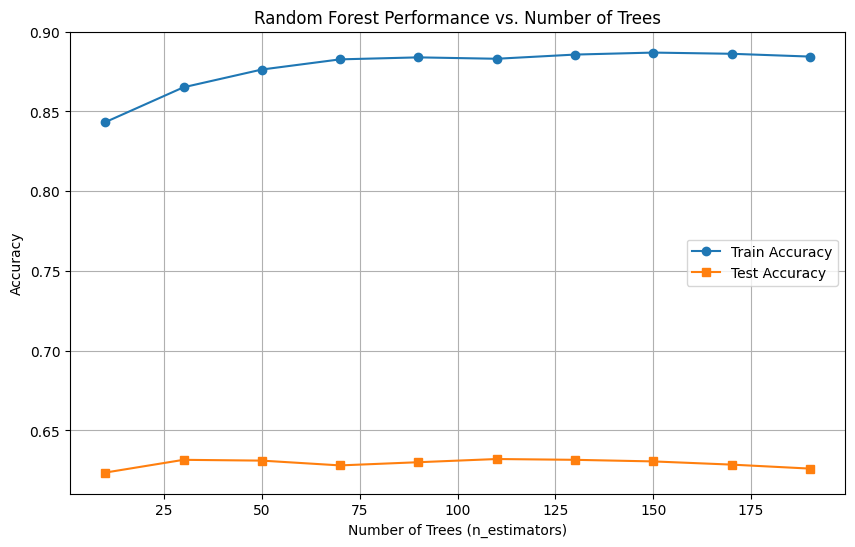

Mean CV Accuracy: 0.6223
Standard Deviation: 0.0075
Mean CV Error: 0.3777
              precision    recall  f1-score   support

           0       0.95      0.21      0.34       278
           1       0.00      0.00      0.00       521
           2       0.62      0.97      0.76      5965
           3       0.64      0.11      0.19      3177
           4       0.00      0.00      0.00        57

    accuracy                           0.62      9998
   macro avg       0.44      0.26      0.26      9998
weighted avg       0.60      0.62      0.52      9998



c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [ ]:
import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.preprocessing import MultiLabelBinarizer


# Downloads 
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')

# Drop non-ASCII languages elements 
df = df[df['orig_lang'].apply(lambda x: x.isascii())]

# Drop duplicates rows 
df = df.drop_duplicates(subset=['names', 'date_x'])

# Convert date and extract year
df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

# Normalize numeric features
df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

# Process genre list and convert the comma delimited genres into an array of words 
df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])

# Bin the rating into classes discretization
def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30: return 0
    elif score < 50: return 1
    elif score < 70: return 2
    elif score < 85: return 3
    else: return 4

# apply the discretization to the dataframe
df['rating_class'] = df['score'].apply(map_rating)

# Clean and lemmatize overview text
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


# cleans up the words for the movie overview descripton and lemmatizes it for more efficient processing 
def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)

df['clean_overview'] = df['overview'].apply(clean_text)

 # Vectorize the movie description using TF-IDF; turns text like "hero saves world" => [0.21, 0.00, 0.45, ...] across 5000 word features
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])


# One-hot encode the genre list so each genre becomes a binary column
# e.g., ['Action', 'Comedy'] => [1, 0, 1, 0] for ['Action', 'Adventure', 'Comedy', 'Drama']
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

# Convert normalized budget and revenue into sparse format for efficient stacking
# e.g., budget 0.45 => [0.45], revenue 0.88 => [0.88]
budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)


# Extract release year from date and one-hot encode it
# e.g., year 2020 => [0, 0, 1, 0] for ['year_2018', 'year_2019', 'year_2020', 'year_2021']

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

year_encoded = pd.get_dummies(df['release_year'], prefix='year')
year_sparse = csr_matrix(year_encoded.values)


# Filter rows with valid labels
valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

# Filter out rows with missing target labels so model only trains on complete data
# Then apply the same mask to each feature matrix to keep everything aligned row-wise
X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
lang_sparse_valid = lang_sparse[valid_rows]
year_sparse_valid = year_sparse[valid_rows]
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

# 2. Stack all features into one matrix
X = hstack([
    X_tfidf_valid,
    genre_sparse_valid,
    budget_sparse_valid,
    revenue_sparse_valid,
    lang_sparse_valid,
    year_sparse_valid
])

# 3. Define target variable
y = df_valid['rating_class']

# 4. Split data — capture indices so we can map predictions back
all_indices = np.arange(X.shape[0])

from sklearn.decomposition import TruncatedSVD

# Reduce TF-IDF dimensionality from 5000 → 200 (for example)
svd = TruncatedSVD(n_components=200, random_state=42)
X_tfidf_reduced = svd.fit_transform(X_tfidf_valid)

# Convert other sparse parts to dense
genre_dense = genre_sparse_valid.toarray()
budget_dense = budget_sparse_valid.toarray()
revenue_dense = revenue_sparse_valid.toarray()
year_dense = year_sparse_valid.toarray()

# Don't forget to define lang_sparse before this step (fix from before)
lang_encoded = pd.get_dummies(df['orig_lang'], prefix='lang')
lang_sparse = csr_matrix(lang_encoded.values)
lang_dense = lang_sparse[valid_rows].toarray()

# Combine all features into a single dense matrix
X_combined = np.hstack([
    X_tfidf_reduced.toarray() if hasattr(X_tfidf_reduced, "toarray") else X_tfidf_reduced,
    genre_dense,
    budget_dense,
    revenue_dense,
    lang_dense,
    year_dense
])

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# co
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Perform 5-fold cross-validation on the full training set
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

# Print the CV performance
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"Mean CV Error: {1 - cv_scores.mean():.4f}")

# Cross-validated predictions on the entire training set (not just the test set)
y_pred_cv = cross_val_predict(rf_model, X_train, y_train, cv=5)

# Classification report for averaged CV predictions
print("\n📊 Cross-Validated Classification Report:")
print(classification_report(y_train, y_pred_cv))
# from sklearn.metrics import accuracy_score
# import matplotlib.pyplot as plt

# # Try different numbers of trees
# n_estimators_list = list(range(10, 210, 20))
# train_accuracies = []
# test_accuracies = []

# for n in n_estimators_list:
#     model = RandomForestClassifier(
#     n_estimators=n,
#     max_depth=15,              # limits overfitting
#     min_samples_leaf=4,        # prevents tiny leaves
#     random_state=42,
#     n_jobs=-1
# )

#     model.fit(X_train, y_train)

#     # Accuracy on training data
#     train_acc = accuracy_score(y_train, model.predict(X_train))
#     train_accuracies.append(train_acc)

#     # Accuracy on test data
#     test_acc = accuracy_score(y_test, model.predict(X_test))
#     test_accuracies.append(test_acc)

# # Plot the error/accuracy curve
# plt.figure(figsize=(10, 6))
# plt.plot(n_estimators_list, train_accuracies, label='Train Accuracy', marker='o')
# plt.plot(n_estimators_list, test_accuracies, label='Test Accuracy', marker='s')
# plt.xlabel('Number of Trees (n_estimators)')
# plt.ylabel('Accuracy')
# plt.title('Random Forest Performance vs. Number of Trees')
# plt.legend()
# plt.grid(True)
# plt.show()
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import cross_val_score
# import numpy as np
# from sklearn.model_selection import cross_val_predict


# # Define the model
# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=15,
#     min_samples_leaf=4,
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_train, y_train)


# # Perform 5-fold cross-validation and use accuracy as the scoring metric
# cv_scores = cross_val_score(rf_model, X_test, y, cv=5, scoring='accuracy')

# # Print the mean accuracy and standard deviation
# print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
# print(f"Standard Deviation: {cv_scores.std():.4f}")
# print(f"Mean CV Error: {1 - cv_scores.mean():.4f}")

# # Get cross-validated predictions
# y_pred = cross_val_predict(rf_model, X, y, cv=5)

# # Print classification report (includes precision, recall, F1-score per class + macro/weighted avg)
# from sklearn.metrics import classification_report
# print(classification_report(y, y_pred))




# # split into training and testing
# X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
#     X, y, all_indices, test_size=0.2, random_state=42
# )
# from sklearn.ensemble import BaggingClassifier
# from sklearn.naive_bayes import ComplementNB

# model = BaggingClassifier(estimator=ComplementNB(), n_estimators=100)
# model.fit(X_train, y_train)

# # --- 5. Train Models ---
# model_mnb = MultinomialNB()
# model_mnb.fit(X_train, y_train)

# model_cnb = ComplementNB()
# model_cnb.fit(X_train, y_train)

# # --- 6. Predict ---
# y_pred_mnb = model_mnb.predict(X_test)
# y_pred_cnb = model_cnb.predict(X_test)

# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score

# # Try different numbers of trees
# n_estimators_list = list(range(10, 210, 20))
# train_accuracies = []
# test_accuracies = []

# for n in n_estimators_list:
#     model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
#     model.fit(X_train, y_train)

#     # Accuracy on training data
#     train_acc = accuracy_score(y_train, model.predict(X_train))
#     train_accuracies.append(train_acc)

#     # Accuracy on test data
#     test_acc = accuracy_score(y_test, model.predict(X_test))
#     test_accuracies.append(test_acc)

# # Plot the error/accuracy curve
# plt.figure(figsize=(10, 6))
# plt.plot(n_estimators_list, train_accuracies, label='Train Accuracy', marker='o')
# plt.plot(n_estimators_list, test_accuracies, label='Test Accuracy', marker='s')
# plt.xlabel('Number of Trees (n_estimators)')
# plt.ylabel('Accuracy')
# plt.title('Random Forest Performance vs. Number of Trees')
# plt.legend()
# plt.grid(True)
# plt.show()


# # --- 7. Inspect Prediction Example ---
# i = 10  # Choose test row to inspect
# original_index = test_idx[i]
# movie = df_valid.iloc[original_index]

# print("🎬 Movie Name:", movie['names'])
# print("📅 Release Date:", movie['date_x'])
# print("🎭 Genres:", movie['genre_list'])
# print("💰 Budget:", movie['budget_x'])
# print("💸 Revenue:", movie['revenue'])
# print("📝 Overview:", movie['overview'][:200], "...")
# print("✅ Actual Rating Class:", y_test.iloc[i])
# print("🤖 MultinomialNB Prediction:", y_pred_mnb[i])
# print("🤖 ComplementNB Prediction:", y_pred_cnb[i])


# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# # Assuming it's a single-label multi-class task (not multilabel)
# cm = confusion_matrix(y_test, y_pred_cnb)
# print("🧾 Confusion Matrix For CNB:\n", cm)

# # Optional: display with labels
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
# disp.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix For CNB without Feature Selection")
# plt.show()

# --- 8. Classification Reports ---
# print("\n📊 Classification Report — MultinomialNB:")
# print(classification_report(y_test, y_pred_mnb))

# print("\n📊 Classification Report — ComplementNB:")
# print(classification_report(y_test, y_pred_cnb))


In [ ]:
import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.preprocessing import MultiLabelBinarizer


# Downloads (comment out if already done)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')

# Drop non-ASCII languages elements 
df = df[df['orig_lang'].apply(lambda x: x.isascii())]

# Drop duplicates rows 
df = df.drop_duplicates(subset=['names', 'date_x'])

# Convert date and extract year
df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

# Normalize numeric features
df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

# Process genre list and convert the comma delimited genres into an array of words 
df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])

# Bin the rating into classes discretization
def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30: return 0
    elif score < 50: return 1
    elif score < 70: return 2
    elif score < 85: return 3
    else: return 4

# apply the discretization to the dataframe
df['rating_class'] = df['score'].apply(map_rating)

# Clean and lemmatize overview text
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


# cleans up the words for the movie overview descripton and lemmatizes it for more efficient processing 
def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)

df['clean_overview'] = df['overview'].apply(clean_text)

 # Vectorize the movie description using TF-IDF; turns text like "hero saves world" => [0.21, 0.00, 0.45, ...] across 5000 word features
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])


# One-hot encode the genre list so each genre becomes a binary column
# e.g., ['Action', 'Comedy'] => [1, 0, 1, 0] for ['Action', 'Adventure', 'Comedy', 'Drama']
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

# Convert normalized budget and revenue into sparse format for efficient stacking
# e.g., budget 0.45 => [0.45], revenue 0.88 => [0.88]
budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)


# Extract release year from date and one-hot encode it
# e.g., year 2020 => [0, 0, 1, 0] for ['year_2018', 'year_2019', 'year_2020', 'year_2021']

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

year_encoded = pd.get_dummies(df['release_year'], prefix='year')
year_sparse = csr_matrix(year_encoded.values)


# Filter rows with valid labels
valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

# Filter out rows with missing target labels so model only trains on complete data
# Then apply the same mask to each feature matrix to keep everything aligned row-wise
X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
lang_sparse_valid = lang_sparse[valid_rows]
year_sparse_valid = year_sparse[valid_rows]
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 2. Stack all features into one matrix
X = hstack([
    X_tfidf_valid,
    genre_sparse_valid,
    budget_sparse_valid,
    revenue_sparse_valid,
    lang_sparse_valid,
    year_sparse_valid
])

# 3. Define target variable
y = df_valid['rating_class']

# 4. Split data — capture indices so we can map predictions back
all_indices = np.arange(X.shape[0])

from sklearn.decomposition import TruncatedSVD

# Reduce TF-IDF dimensionality from 5000 → 200 (for example)
svd = TruncatedSVD(n_components=200, random_state=42)
X_tfidf_reduced = svd.fit_transform(X_tfidf_valid)

# Convert other sparse parts to dense
genre_dense = genre_sparse_valid.toarray()
budget_dense = budget_sparse_valid.toarray()
revenue_dense = revenue_sparse_valid.toarray()
year_dense = year_sparse_valid.toarray()

# Don't forget to define lang_sparse before this step (fix from before)
lang_encoded = pd.get_dummies(df['orig_lang'], prefix='lang')
lang_sparse = csr_matrix(lang_encoded.values)
lang_dense = lang_sparse[valid_rows].toarray()
from sklearn.model_selection import cross_val_predict,cross_val_score
from sklearn.metrics import classification_report


# Combine all features into a single dense matrix
X_combined = np.hstack([
    X_tfidf_reduced.toarray() if hasattr(X_tfidf_reduced, "toarray") else X_tfidf_reduced,
    genre_dense,
    budget_dense,
    revenue_dense,
    lang_dense,
    year_dense
])

import matplotlib.pyplot as plt 


# Try different numbers of trees
n_estimators_list = list(range(10, 210, 20))
train_accuracies = []
test_accuracies = []

for n in n_estimators_list:
    model = RandomForestClassifier(
    n_estimators=n,
    max_depth=15,              # limits overfitting
    min_samples_leaf=4,        # prevents tiny leaves
    random_state=42,
    n_jobs=-1
)

    model.fit(X_train, y_train)

    # Accuracy on training data
    train_acc = accuracy_score(y_train, model.predict(X_train))
    train_accuracies.append(train_acc)

    # Accuracy on test data
    test_acc = accuracy_score(y_test, model.predict(X_test))
    test_accuracies.append(test_acc)

# Plot the error/accuracy curve
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(n_estimators_list, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance vs. Number of Trees')
plt.legend()
plt.grid(True)
plt.show()


# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# Define the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)



# Perform cross-validation on the training set (optional, for internal validation)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Mean CV Error: {1 - cv_scores.mean():.4f}")

# Train final model on full training set
rf_model.fit(X_train, y_train)

# Predict on the test set
y_test_pred = rf_model.predict(X_test)

# Generate test set classification report
print("\n📊 Final Test Set Classification Report: before Feature Selection")
print(classification_report(y_test,y_test_pred))


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scipy.sparse import hstack

# define all the features and conduct forward selection
feature_blocks = {
    'tfidf': X_tfidf_valid,
    'genres': genre_sparse_valid,
    'budget': budget_sparse_valid,
    'revenue': revenue_sparse_valid,
    'year': year_sparse_valid
}

selected = []
remaining = list(feature_blocks.keys())
best_score = 0

print("🌲 FORWARD FEATURE SELECTION — Random Forest")
while remaining:
    scores = []
    for feat in remaining:
        # Try adding each remaining feature block
        X_try = hstack([feature_blocks[f] for f in selected + [feat]])
        
        # Convert to dense for Random Forest
        X_try_dense = X_try.toarray() if hasattr(X_try, "toarray") else X_try
        
        # Evaluate using cross-validation (using accuracy or f1_macro depending on goal)
        score = cross_val_score(
            RandomForestClassifier(
                n_estimators=100,
                max_depth=15,
                min_samples_leaf=4,
                random_state=42,
                n_jobs=-1
            ),
            X_try_dense,
            y,
            cv=3,
            scoring='f1_macro'
        ).mean()
        
        scores.append((feat, score))

    best_feat, best_feat_score = max(scores, key=lambda x: x[1])
    if best_feat_score > best_score:
        selected.append(best_feat)
        remaining.remove(best_feat)
        best_score = best_feat_score
        print(f"✅ Added: {best_feat} (F1 = {best_feat_score:.4f})")
    else:
        print("⛔ No improvement — stopping selection.")
        break

print(f"\n✅ Final selected features: {selected}")

# select only the features determined by forward selection
X_selected = hstack([feature_blocks[f] for f in selected])

# split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)


# Define the Random Forest model (set n estimator to 100 based on analysis of graph)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

# Train and predict
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Output classification report
print("\n📊 Classification Report (Forward Selection + Random Forest):")
print(classification_report(y_test, y_pred))





[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Mean CV Accuracy: 0.6235
Mean CV Error: 0.3765

📊 Final Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.19      0.32        42
           1       0.00      0.00      0.00       107
           2       0.63      0.96      0.76      1209
           3       0.62      0.14      0.23       632
           4       0.00      0.00      0.00        10

    accuracy                           0.63      2000
   macro avg       0.45      0.26      0.26      2000
weighted avg       0.60      0.63      0.54      2000

🌲 FORWARD FEATURE SELECTION — Random Forest


c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

✅ Added: revenue (F1 = 0.5210)
✅ Added: budget (F1 = 0.5611)
⛔ No improvement — stopping selection.

✅ Final selected features: ['revenue', 'budget']

📊 Classification Report (Forward Selection + Random Forest):
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        42
           1       0.77      0.35      0.48       107
           2       0.69      0.87      0.77      1209
           3       0.55      0.33      0.41       632
           4       0.75      0.30      0.43        10

    accuracy                           0.67      2000
   macro avg       0.74      0.54      0.59      2000
weighted avg       0.65      0.67      0.64      2000



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


🔍 FORWARD SELECTION STARTED
✅ Added: tfidf (F1 = 0.2758)
✅ Added: year (F1 = 0.3233)
✅ Added: genres (F1 = 0.3346)
⛔ No improvement — stopping selection.

✅ Final selected features: ['tfidf', 'year', 'genres']

📊 Classification Report (Forward Selection):
              precision    recall  f1-score   support

           0       0.36      0.50      0.42        42
           1       0.06      0.01      0.02       107
           2       0.72      0.69      0.71      1209
           3       0.50      0.61      0.55       632
           4       0.00      0.00      0.00        10

    accuracy                           0.62      2000
   macro avg       0.33      0.36      0.34      2000
weighted avg       0.61      0.62      0.61      2000

🧾 Confusion Matrix For CNB:
 [[ 21   0   8  13   0]
 [ 10   1  73  23   0]
 [ 20  12 834 343   0]
 [  6   3 238 385   0]
 [  2   1   3   4   0]]


c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

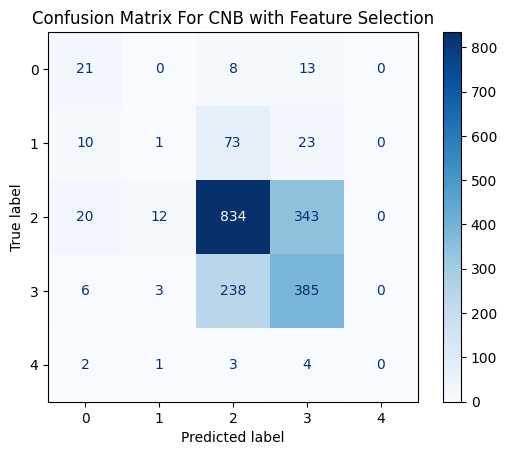

In [62]:
import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# Downloads (comment out if already done)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')
df = df[df['orig_lang'].apply(lambda x: x.isascii())]
df = df.drop_duplicates(subset=['names', 'date_x'])
df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])


def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30:
        return 0
    elif score < 50:
        return 1
    elif score < 70:
        return 2
    elif score < 85:
        return 3
    else:
        return 4


df['rating_class'] = df['score'].apply(map_rating)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)


df['clean_overview'] = df['overview'].apply(clean_text)

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)
year_encoded = pd.get_dummies(df['release_year'], prefix='year')
year_sparse = csr_matrix(year_encoded.values)

valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
year_sparse_valid = year_sparse[valid_rows]

y = df_valid['rating_class']

# === FORWARD SELECTION ===

feature_blocks = {
    'tfidf': X_tfidf_valid,
    'genres': genre_sparse_valid,
    'budget': budget_sparse_valid,
    'revenue': revenue_sparse_valid,
    'year': year_sparse_valid
}

selected = []
remaining = list(feature_blocks.keys())
best_score = 0

print("🔍 FORWARD SELECTION STARTED")
while remaining:
    scores = []
    for feat in remaining:
        X_try = hstack([feature_blocks[f] for f in selected + [feat]])
        score = cross_val_score(
            OneVsRestClassifier(ComplementNB()),
            X_try, y, cv=3, scoring='f1_macro'
        ).mean()
        scores.append((feat, score))

    best_feat, best_feat_score = max(scores, key=lambda x: x[1])
    if best_feat_score > best_score:
        selected.append(best_feat)
        remaining.remove(best_feat)
        best_score = best_feat_score
        print(f"✅ Added: {best_feat} (F1 = {best_feat_score:.4f})")
    else:
        print("⛔ No improvement — stopping selection.")
        break

print(f"\n✅ Final selected features: {selected}")

X_selected = hstack([feature_blocks[f] for f in selected])
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import ComplementNB

model = OneVsRestClassifier(ComplementNB())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n📊 Classification Report (Forward Selection):")
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming it's a single-label multi-class task (not multilabel)
cm = confusion_matrix(y_test, y_pred)
print("🧾 Confusion Matrix For CNB:\n", cm)

# Optional: display with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix For CNB with Feature Selection")
plt.show()

